# <font style="color:black">Peningkatan Citra Dasar Menggunakan Operasi Matematika</font>
Teknik-teknik pengolahan citra memanfaatkan operasi matematika untuk mencapai berbagai hasil. Paling sering, kita memperoleh versi citra yang lebih baik dengan menggunakan beberapa operasi dasar. Kita akan mempelajari beberapa operasi fundamental yang sering digunakan dalam pipeline computer vision. Dalam notebook ini kita akan membahas:

* Operasi Aritmatika seperti penjumlahan (addition) dan perkalian (multiplication)
* Thresholding & Masking
* Operasi Bitwise seperti OR, AND, XOR

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image
print("hello world")

hello world


### <font color="green">Citra Asli (Original Image)</font>

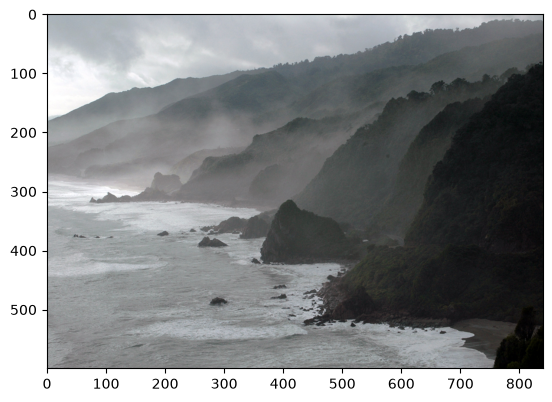

In [5]:
bahan_bgr = cv2.imread("gambar/New_Zealand_Coast.jpg", cv2.IMREAD_COLOR)
bahan_rgb = cv2.cvtColor(bahan_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(bahan_rgb)

## Penjumlahan (Addition) atau Kecerahan (Brightness)
Operasi pertama yang kita bahas adalah penjumlahan sederhana pada citra. Hal ini menghasilkan peningkatan atau penurunan kecerahan citra karena pada dasarnya kita menambah atau mengurangi nilai intensitas setiap piksel dengan jumlah yang sama. Sehingga, hal ini akan menghasilkan peningkatan/penurunan kecerahan secara global.

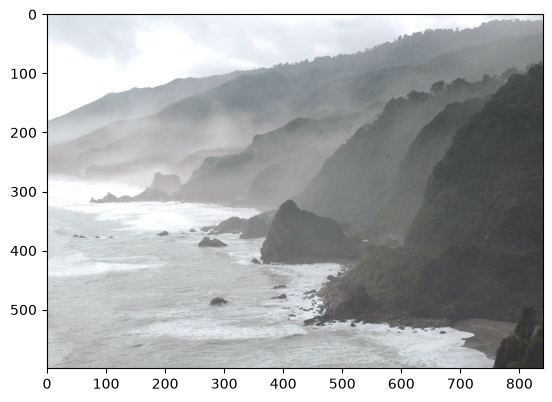

In [6]:
matrik_bantu = np.ones(bahan_rgb.shape, dtype="uint8") * 50

cerah = cv2.add(bahan_rgb, matrik_bantu)

plt.imshow(cerah)

## Perkalian (Multiplication) atau Kontras (Contrast)
Sama seperti penjumlahan dapat menghasilkan perubahan kecerahan, perkalian dapat digunakan untuk meningkatkan kontras citra.

Kontras adalah selisih nilai intensitas antar piksel pada suatu citra. Mengalikan nilai intensitas dengan suatu konstanta dapat memperbesar atau memperkecil selisih tersebut (jika faktor pengali < 1).

### <font color="green">Apa yang terjadi?</font>
Bisakah kamu melihat warna-warna aneh di beberapa bagian citra setelah proses perkalian?

Masalahnya adalah setelah dikalikan, nilai-nilai yang sudah tinggi menjadi lebih besar dari 255. Sehingga terjadi masalah overflow. Bagaimana cara mengatasinya?

### <font color="green">Menangani Overflow menggunakan np.clip</font>

## Thresholding Citra
Citra biner (Binary Images) memiliki banyak kegunaan dalam Pengolahan Citra. Salah satu kegunaan yang paling umum adalah untuk membuat mask (masking). Mask citra memungkinkan kita untuk memproses bagian tertentu dari suatu citra sambil menjaga bagian lainnya tetap utuh. Thresholding Citra digunakan untuk membuat citra biner dari citra grayscale. Kamu dapat menggunakan nilai threshold yang berbeda-beda untuk menghasilkan citra biner yang berbeda dari citra asli yang sama.

### <font color="green">Sintaks Fungsi</font>

``` python
retval, dst = cv2.threshold( src, thresh, maxval, type[, dst] )
```

`dst`: Array keluaran dengan ukuran, tipe, dan jumlah channel yang sama dengan `src`.

Fungsi ini memiliki **4 argumen wajib**:

1. `src`: array masukan (multi-channel, 8-bit atau 32-bit floating point).

2. `thresh`: nilai threshold.

3. `maxval`: nilai maksimum yang digunakan untuk tipe thresholding THRESH_BINARY dan THRESH_BINARY_INV.

4. `type`: tipe thresholding (lihat ThresholdTypes).


### <font color="green">Sintaks Fungsi</font>

``` python
dst = cv.adaptiveThreshold( src, maxValue, adaptiveMethod, thresholdType, blockSize, C[, dst] )
```

`dst`: Citra tujuan dengan ukuran dan tipe yang sama dengan src.

Fungsi ini memiliki **6 argumen wajib**:
1. `src`: Citra sumber 8-bit satu channel (single-channel).

2. `maxValue`: Nilai bukan nol yang diberikan pada piksel yang memenuhi kondisi.

3. `adaptiveMethod`: Algoritma adaptive thresholding yang digunakan, lihat AdaptiveThresholdTypes. BORDER_REPLICATE | BORDER_ISOLATED digunakan untuk memproses batas (boundaries).

4. `thresholdType`: Tipe thresholding yang harus berupa THRESH_BINARY atau THRESH_BINARY_INV, lihat ThresholdTypes.

5. `blockSize`: Ukuran wilayah tetangga piksel (pixel neighborhood) yang digunakan untuk menghitung nilai threshold untuk piksel tersebut: 3, 5, 7, dan seterusnya.

6. `C`: Konstanta yang dikurangkan dari nilai rata-rata atau rata-rata berbobot (lihat detail di bawah). Biasanya bernilai positif, namun bisa juga nol atau negatif.

### <font style="color:rgb(8,133,37)">Dokumentasi OpenCV</font>

<a href="https://docs.opencv.org/4.5.1/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57
https://docs.opencv.org/4.5.1/d7/d4d/tutorial_py_thresholding.html" target="_blank">Tautan dokumentasi</a>

## Aplikasi: Pembaca Not Balok (Sheet Music Reader)
Bayangkan kamu ingin membuat aplikasi yang dapat membaca (men-decode) not balok. Ini mirip dengan Optical Character Recognition (OCR) untuk dokumen teks, di mana tujuannya adalah mengenali karakter-karakter teks. Pada kedua aplikasi tersebut, salah satu langkah pertama dalam pipeline pemrosesan adalah mengisolasi informasi penting dalam citra dokumen (memisahkannya dari latar belakang). Tugas ini dapat dicapai dengan teknik thresholding. Mari kita lihat contohnya.

## Operasi Bitwise

### <font style="color:rgb(8,133,37)">Sintaks Fungsi</font>

Contoh API untuk `cv2.bitwise_and()`. Lainnya termasuk: `cv2.bitwise_or()`, `cv2.bitwise_xor()`, `cv2.bitwise_not()`

``` python
dst = cv2.bitwise_and( src1, src2[, dst[, mask]] )
```

`dst`: Array keluaran dengan ukuran dan tipe yang sama dengan array masukan.

Fungsi ini memiliki **2 argumen wajib**:

1. `src1`: array masukan pertama atau skalar.

2. `src2`: array masukan kedua atau skalar.

Argumen opsional yang penting:

1. `mask`: mask operasi opsional, array 8-bit satu channel, yang menentukan elemen array keluaran mana yang akan diubah.


### <font style="color:rgb(8,133,37)">Dokumentasi OpenCV</font>

1. <a href="https://docs.opencv.org/4.5.1/d0/d86/tutorial_py_image_arithmetics.html" target="_blank">Operasi Aritmatika pada Citra</a>

2. <a href="https://docs.opencv.org/4.5.0/d2/de8/group__core__array.html#ga60b4d04b251ba5eb1392c34425497e14" target="_blank">Fungsi bitwise_and(...)</a>

### <font color="green">Operator Bitwise AND</font>

### <font color="green">Operator Bitwise OR</font>

### <font color="green">Operator Bitwise XOR</font>

## Aplikasi: Manipulasi Logo

Pada bagian ini kita akan menunjukkan cara mengisi tulisan putih pada logo Coca-Cola di bawah ini dengan sebuah citra latar belakang.

### <font color="green">Membaca Citra Foreground (Latar Depan)</font>

### <font color="green">Membaca Citra Background (Latar Belakang)</font>

### <font color="green">Membuat Mask untuk Citra Asli</font>

### <font color="green">Membalik (Invert) Mask</font>

### <font color="green">Menerapkan Background pada Mask</font>

### <font color="green">Mengisolasi Foreground dari Citra</font>

### <font color="green">Hasil: Menggabungkan Foreground dan Background</font>

## Terima Kasih!